# Bibliotecas

In [3]:
import pandas as pd
import numpy as np
import sklearn
import keras
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler

from keras import layers
from keras.layers import Input, Dropout, Dense, BatchNormalization
from keras.models import Sequential
from keras import regularizers
from keras.callbacks import EarlyStopping

# Questão 3

## Divisão do conjunto de treino em treino e validação

In [4]:
treino = pd.read_csv('data/fashion-mnist_train.csv')
teste = pd.read_csv('data/fashion-mnist_test.csv')

treino, validacao = train_test_split(treino, random_state=42, test_size=0.2)

In [5]:
treino

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
48572,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38696,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13611,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
35213,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31766,2,0,0,0,0,0,0,0,0,1,...,0,0,1,0,11,37,6,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54343,2,0,0,0,0,0,3,7,0,0,...,174,180,196,235,0,0,255,229,166,0
38158,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
860,9,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
15795,4,0,0,0,0,0,0,0,2,0,...,94,74,0,0,0,0,0,0,0,0


In [6]:
validacao

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
12628,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
37730,8,0,0,0,0,0,0,0,0,0,...,187,190,196,201,209,221,218,211,102,0
39991,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8525,5,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
8279,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49914,6,0,0,0,0,0,0,0,0,0,...,53,0,0,0,0,0,0,0,0,0
34428,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
45810,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30357,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
teste

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## Identificação de valores ausentes

In [8]:
ausentes_treino = treino.isnull().sum()
pct_ausentes_treino = (ausentes_treino / len(treino)) * 100

pct_ausentes_treino_df = pd.DataFrame({'Coluna': ausentes_treino.index, 'Ausentes': ausentes_treino.values, 'Porcentagem': pct_ausentes_treino.values}).query('Ausentes > 0')
pct_ausentes_treino_df

,Coluna,Ausentes,Porcentagem


In [9]:
ausentes_validacao = validacao.isnull().sum()
pct_ausentes_validacao = (ausentes_validacao / len(validacao)) * 100

pct_ausentes_validacao_df = pd.DataFrame({'Coluna': ausentes_validacao.index, 'Ausentes': ausentes_validacao.values, 'Porcentagem': pct_ausentes_validacao.values}).query('Ausentes > 0')
pct_ausentes_validacao_df

,Coluna,Ausentes,Porcentagem


In [10]:
ausentes_teste = teste.isnull().sum()
pct_ausentes_teste = (ausentes_teste / len(teste)) * 100

pct_ausentes_teste_df = pd.DataFrame({'Coluna': ausentes_teste.index, 'Ausentes': ausentes_teste.values, 'Porcentagem': pct_ausentes_teste.values}).query('Ausentes > 0')
pct_ausentes_teste_df

,Coluna,Ausentes,Porcentagem


## Conversão dos DataFrames em arrays numpy

In [11]:
X_treino = np.array(treino.drop(['label'], axis = 1))
y_treino = np.array(treino['label'])

X_val = np.array(validacao.drop(['label'], axis = 1))
y_val = np.array(validacao['label'])

X_teste = np.array(teste.drop(['label'], axis = 1))
y_teste = np.array(teste['label'])

print(f"Quantidade de amostras para treino: {X_treino.shape[0]}")
print(f"Quantidade de amostras para validação: {X_val.shape[0]}")
print(f"Quantidade de amostras para teste: {X_teste.shape[0]}")

Quantidade de amostras para treino: 48000
Quantidade de amostras para validação: 12000
Quantidade de amostras para teste: 10000


## Normalização ou padronização dos atributos numéricos

In [12]:
stat, p = stats.normaltest(treino['pixel1'].dropna())

print(f'Estatística: {stat:.4f}')
print(f'P-valor: {p:.4f}')

if p > 0.05:
    print('Os valores da coluna "pixel1" seguem distribuição normal')
else:
    print('Os valores da coluna "pixel1" não seguem distribuição normal')

Estatística: 208361.2501
P-valor: 0.0000
Os valores da coluna "pixel1" não seguem distribuição normal


In [13]:
scaler = MinMaxScaler()

X_treino = scaler.fit_transform(X_treino)
X_val = scaler.transform(X_val)
X_teste = scaler.transform(X_teste)

## 3.1. Arquitetura da rede neural respeitando a dimensão VC

In [14]:
model1 = Sequential()

model1.add(Input(shape=(784,)))

model1.add(Dense(6, kernel_initializer='he_normal', activation='relu'))

model1.add(Dense(3, kernel_initializer='he_normal', activation='relu'))

model1.add(Dense(10, kernel_initializer='he_normal', activation='softmax'))

initial_weights = model1.get_weights()

model1.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model1.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │         4,710 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            40 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,771 (18.64 KB)

 Trainable params: 4,771 (18.64 KB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model1.set_weights(initial_weights)
history = model1.fit(X_treino, y_treino, epochs=100, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4827 - loss: 1.3546 - val_accuracy: 0.6597 - val_loss: 1.0097
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7265 - loss: 0.8220 - val_accuracy: 0.7457 - val_loss: 0.7485
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7659 - loss: 0.7000 - val_accuracy: 0.7606 - val_loss: 0.6972
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7842 - loss: 0.6501 - val_accuracy: 0.7807 - val_loss: 0.6566
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7900 - loss: 0.6221 - val_accuracy: 0.7732 - val_loss: 0.6608
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7939 - loss: 0.6036 - val_accuracy: 0.7836 - val_loss: 0.6254
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8012 - loss: 0.5864 - val_accuracy: 0.7897 - val_loss: 0.6102
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8042 - loss: 

### Curva de erro de treinamento e validação

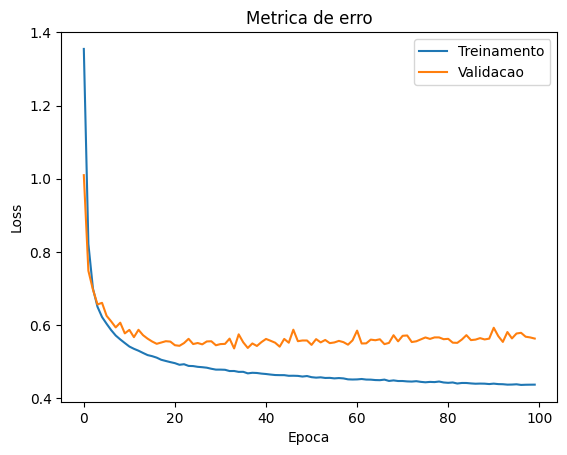


-> Loss_treino = 0.4270
-> Loss_val = 0.5633
-> Loss_val - Loss_treino = 0.1363

-> E_in = 0.1475
-> E_val = 0.1732
-> E_val - E_in = 0.0257

-> Acc_treino: 0.8525
-> Acc_val: 0.8268
-> Acc_treino - Acc_val = 0.0257


In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Loss')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

loss_train, acc_train = model1.evaluate(X_treino, y_treino, batch_size=32, verbose=0)

loss_val, acc_val = model1.evaluate(X_val, y_val, batch_size=32, verbose=0)

e_in = 1 - acc_train
e_val = 1 - acc_val

print(f"\n-> Loss_treino = {loss_train:.4f}")
print(f"-> Loss_val = {loss_val:.4f}")
print(f"-> Loss_val - Loss_treino = {loss_val - loss_train:.4f}\n")

print(f"-> E_in = {e_in:.4f}")
print(f"-> E_val = {e_val:.4f}")
print(f"-> E_val - E_in = {e_val - e_in:.4f}\n")

print(f'-> Acc_treino: {acc_train:.4f}')
print(f'-> Acc_val: {acc_val:.4f}')
print(f"-> Acc_treino - Acc_val = {acc_train - acc_val:.4f}")

### Matriz de confusão

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


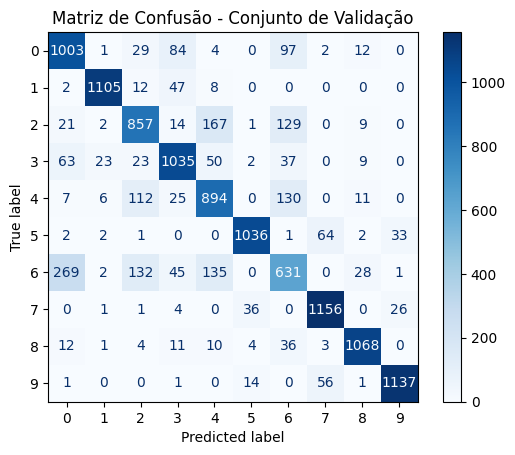

In [17]:
y_pred_val = np.argmax(model1.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Validação')
plt.show()

### Métricas de erro

In [18]:
y_pred_teste = np.argmax(model1.predict(X_teste), axis=1)

acc = accuracy_score(y_teste, y_pred_teste)
prec = precision_score(y_teste, y_pred_teste, average='macro', zero_division=0)
rec = recall_score(y_teste, y_pred_teste, average='macro', zero_division=0)
f1 = f1_score(y_teste, y_pred_teste, average='macro', zero_division=0)

print(f"-> Accuracy: {acc:.4f}")
print(f"-> Precision: {prec:.4f}")
print(f"-> Recall: {rec:.4f}")
print(f"-> F1-score: {f1:.4f}\n")

print("Relatório de classificação completo:")
print(classification_report(y_teste, y_pred_teste, target_names=[str(i) for i in range(10)]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
-> Accuracy: 0.8280
-> Precision: 0.8271
-> Recall: 0.8280
-> F1-score: 0.8266

Relatório de classificação completo:
              precision    recall  f1-score   support

           0       0.72      0.81      0.76      1000
           1       0.96      0.96      0.96      1000
           2       0.74      0.72      0.73      1000
           3       0.83      0.84      0.84      1000
           4       0.73      0.77      0.75      1000
           5       0.95      0.88      0.92      1000
           6       0.61      0.52      0.56      1000
           7       0.86      0.93      0.89      1000
           8       0.94      0.93      0.93      1000
           9       0.93      0.93      0.93      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



## 3.2. Arquitetura da rede neural com overfitting e regularização

In [19]:
model2 = Sequential()

model2.add(Input(shape=(784,)))

model2.add(Dense(256, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Dropout(0.2))

model2.add(Dense(128, kernel_initializer='he_normal', activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model2.add(BatchNormalization())
model2.add(Dropout(0.2))

model2.add(Dense(10, kernel_initializer='he_normal', activation='softmax'))

initial_weights = model2.get_weights()

model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model2.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,682 (924.54 KB)

 Trainable params: 235,914 (921.54 KB)

 Non-trainable params: 768 (3.00 KB)

None


In [29]:
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

model2.set_weights(initial_weights)
history = model2.fit(X_treino, y_treino, epochs=100, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8016 - loss: 1.0134 - val_accuracy: 0.7702 - val_loss: 0.8583
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8341 - loss: 0.6822 - val_accuracy: 0.8323 - val_loss: 0.6312
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8375 - loss: 0.6019 - val_accuracy: 0.8336 - val_loss: 0.5879
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8426 - loss: 0.5582 - val_accuracy: 0.8220 - val_loss: 0.6021
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8443 - loss: 0.5326 - val_accuracy: 0.8363 - val_loss: 0.5422
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8452 - loss: 0.5169 - val_accuracy: 0.8381 - val_loss: 0.5312
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8474 - loss: 0.5081 - val_accuracy: 0.8458 - val_loss: 0.5188
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8512 - loss: 0.4957 - val_a

### Curva de erro de treinamento e validação

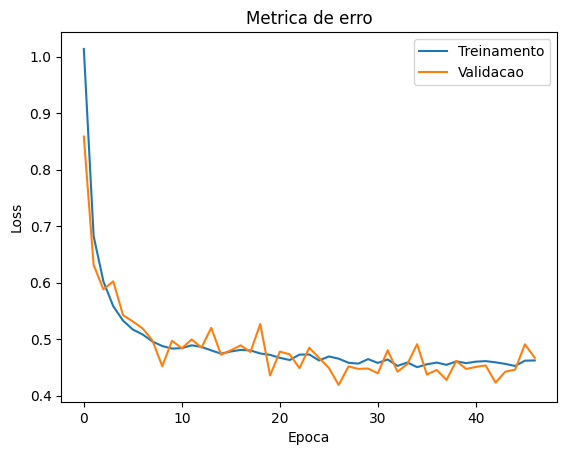


-> Loss_treino = 0.3874
-> Loss_val = 0.4188
-> Loss_val - Loss_treino = 0.0314

-> E_in = 0.1163
-> E_val = 0.1300
-> E_val - E_in = 0.0137

-> Acc_treino: 0.8837
-> Acc_val: 0.8700
-> Acc_treino - Acc_val = 0.0137


In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Loss')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

loss_train, acc_train = model2.evaluate(X_treino, y_treino, batch_size=64, verbose=0)

loss_val, acc_val = model2.evaluate(X_val, y_val, batch_size=64, verbose=0)

e_in = 1 - acc_train
e_val = 1 - acc_val

print(f"\n-> Loss_treino = {loss_train:.4f}")
print(f"-> Loss_val = {loss_val:.4f}")
print(f"-> Loss_val - Loss_treino = {loss_val - loss_train:.4f}\n")

print(f"-> E_in = {e_in:.4f}")
print(f"-> E_val = {e_val:.4f}")
print(f"-> E_val - E_in = {e_val - e_in:.4f}\n")

print(f'-> Acc_treino: {acc_train:.4f}')
print(f'-> Acc_val: {acc_val:.4f}')
print(f"-> Acc_treino - Acc_val = {acc_train - acc_val:.4f}")

### Matriz de confusão

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


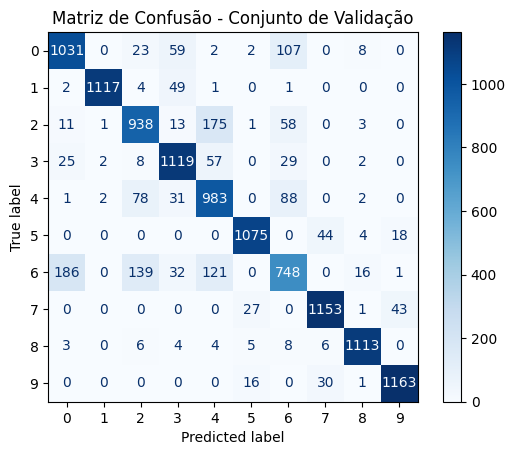

In [34]:
y_pred_val = np.argmax(model2.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Validação')
plt.show()

### Métricas de erro

In [32]:
y_pred_teste = np.argmax(model2.predict(X_teste), axis=1)

acc = accuracy_score(y_teste, y_pred_teste)
prec = precision_score(y_teste, y_pred_teste, average='macro', zero_division=0)
rec = recall_score(y_teste, y_pred_teste, average='macro', zero_division=0)
f1 = f1_score(y_teste, y_pred_teste, average='macro', zero_division=0)

print(f"-> Accuracy: {acc:.4f}")
print(f"-> Precision: {prec:.4f}")
print(f"-> Recall: {rec:.4f}")
print(f"-> F1-score: {f1:.4f}\n")

print("Relatório de classificação completo:")
print(classification_report(y_teste, y_pred_teste, target_names=[str(i) for i in range(10)]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
-> Accuracy: 0.8725
-> Precision: 0.8720
-> Recall: 0.8725
-> F1-score: 0.8713

Relatório de classificação completo:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82      1000
           1       0.99      0.97      0.98      1000
           2       0.79      0.78      0.79      1000
           3       0.88      0.91      0.90      1000
           4       0.77      0.86      0.81      1000
           5       0.96      0.93      0.94      1000
           6       0.75      0.62      0.68      1000
           7       0.92      0.91      0.91      1000
           8       0.95      0.96      0.96      1000
           9       0.91      0.95      0.93      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



## 3.3. Arquitetura da rede convolucional

In [ ]:
rotulos_treino = treino.iloc[:, 0]  
imagens_treino = X_treino.reshape(-1, 28, 28, 1)

In [ ]:
modelo = Sequential([
    layers.Input((28,28,1)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

In [53]:
adam = keras.optimizers.Adam(learning_rate=0.001)

modelo.compile(
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              optimizer=adam)

historico = modelo.fit(
    imagens_treino, 
    rotulos_treino, 
    epochs=20,           
    batch_size=32,      
    validation_data=(X_val.reshape(-1, 28, 28, 1), y_val)
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6883 - loss: 0.8100 - val_accuracy: 0.8574 - val_loss: 0.3945
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.8081 - loss: 0.5147 - val_accuracy: 0.8702 - val_loss: 0.3471
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8487 - loss: 0.4192 - val_accuracy: 0.8934 - val_loss: 0.2852
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.8708 - loss: 0.3576 - val_accuracy: 0.9047 - val_loss: 0.2567
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.8831 - loss: 0.3253 - val_accuracy: 0.9092 - val_loss: 0.2422
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.8941 - loss: 0.2957 - val_accuracy: 0.9147 - val_loss: 0.2339
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.8992 - loss: 0.2799 - val_accuracy: 0.9150 - val_loss: 0.2306
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.9062 -

In [54]:
modelo.save('modelo_cnn.keras')

### Curva de erro de treinamento e validação

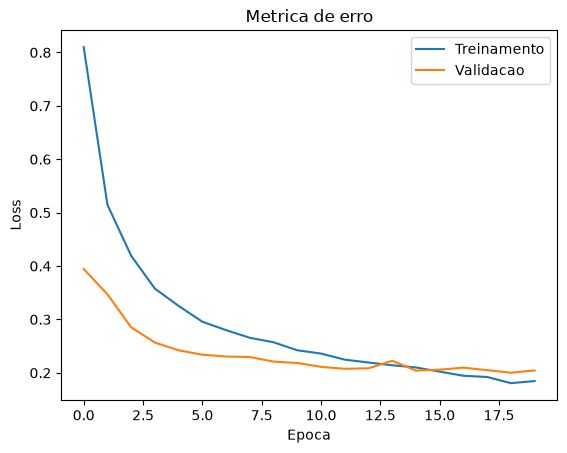


-> Loss_treino = 0.1076
-> Loss_val = 0.2044
-> Loss_val - Loss_treino = 0.0968

-> E_in = 0.0404
-> E_val = 0.0717
-> E_val - E_in = 0.0313

-> Acc_treino: 0.9596
-> Acc_val: 0.9283
-> Acc_treino - Acc_val = 0.0313


In [72]:
plt.plot(historico.history['loss'])
plt.plot(historico.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Loss')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

X_treino = X_treino.reshape(-1, 28, 28, 1)
X_val = X_val.reshape(-1, 28, 28, 1)


loss_train, acc_train = modelo.evaluate(X_treino, y_treino, batch_size=32, verbose=0)

loss_val, acc_val = modelo.evaluate(X_val, y_val, batch_size=32, verbose=0)

e_in = 1 - acc_train
e_val = 1 - acc_val

print(f"\n-> Loss_treino = {loss_train:.4f}")
print(f"-> Loss_val = {loss_val:.4f}")
print(f"-> Loss_val - Loss_treino = {loss_val - loss_train:.4f}\n")

print(f"-> E_in = {e_in:.4f}")
print(f"-> E_val = {e_val:.4f}")
print(f"-> E_val - E_in = {e_val - e_in:.4f}\n")

print(f'-> Acc_treino: {acc_train:.4f}')
print(f'-> Acc_val: {acc_val:.4f}')
print(f"-> Acc_treino - Acc_val = {acc_train - acc_val:.4f}")

### Matriz de confusão

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


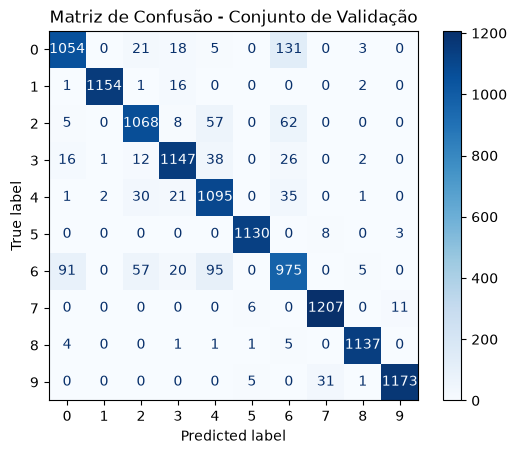

In [73]:
y_pred_val = np.argmax(modelo.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Conjunto de Validação')
plt.show()

### Métricas de erro

In [76]:
X_teste = X_teste.reshape(-1, 28, 28, 1)

y_pred_teste = np.argmax(modelo.predict(X_teste), axis=1)

acc = accuracy_score(y_teste, y_pred_teste)
prec = precision_score(y_teste, y_pred_teste, average='macro', zero_division=0)
rec = recall_score(y_teste, y_pred_teste, average='macro', zero_division=0)
f1 = f1_score(y_teste, y_pred_teste, average='macro', zero_division=0)

print(f"-> Accuracy: {acc:.4f}")
print(f"-> Precision: {prec:.4f}")
print(f"-> Recall: {rec:.4f}")
print(f"-> F1-score: {f1:.4f}\n")

print("Relatório de classificação completo:")
print(classification_report(y_teste, y_pred_teste, target_names=[str(i) for i in range(10)]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
-> Accuracy: 0.9334
-> Precision: 0.9341
-> Recall: 0.9334
-> F1-score: 0.9335

Relatório de classificação completo:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1000
           1       0.99      1.00      1.00      1000
           2       0.92      0.88      0.90      1000
           3       0.95      0.93      0.94      1000
           4       0.86      0.93      0.89      1000
           5       0.99      0.99      0.99      1000
           6       0.79      0.80      0.80      1000
           7       0.97      0.97      0.97      1000
           8       0.99      0.99      0.99      1000
           9       0.98      0.98      0.98      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

